## Data Cleaning, Preprocessing, Integrasi Notebook (OLBY)

In [1]:
# upload dataset

! wget https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

--2026-06-05 20:17:05--  https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
Resolving www.kaggle.com (www.kaggle.com)... 35.244.233.98
Connecting to www.kaggle.com (www.kaggle.com)|35.244.233.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘pima-indians-diabetes-database’

pima-indians-diabet     [ <=>                ]  10.49K  --.-KB/s    in 0s      

2026-06-05 20:17:06 (77.4 MB/s) - ‘pima-indians-diabetes-database’ saved [10744]



In [2]:
import pandas as pd
import numpy as np

import kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


In [3]:
df = pd.read_csv(path + "/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# cek missing value
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
# mengubah nilai 0 menjadi NaN

kolom = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for i in kolom:
  df[i] = df[i].replace(0, np.nan)

In [7]:
# cek missing value setelah replace

df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
# handling missing value

for col in kolom:
  df.loc[(df['Outcome']==0) & (df[col].isna()), col] = df[df['Outcome']==0][col].mean()
  df.loc[(df['Outcome']==1) & (df[col].isna()), col] = df[df['Outcome']==1][col].mean()

In [9]:
# feature dan target

X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [10]:
# normalisasi data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

## EDA dan Visualisasi Data (SHAFA)


In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.000000
mean,3.845052,121.697358,72.428141,29.247042,157.003527,32.44642,0.471876,33.240885,0.348958
std,3.369578,30.462008,12.106044,8.923908,88.860914,6.87897,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.20000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.50000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,130.287879,32.05000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,33.000000,206.846154,36.60000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.10000,2.420000,81.000000,1.000000


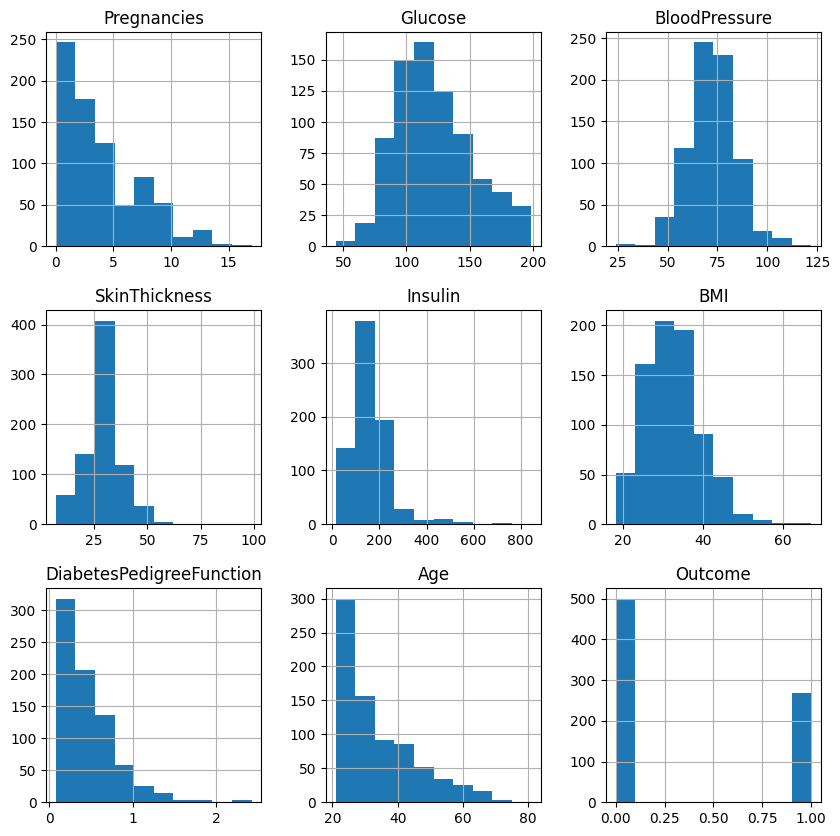

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(10,10))
plt.show()

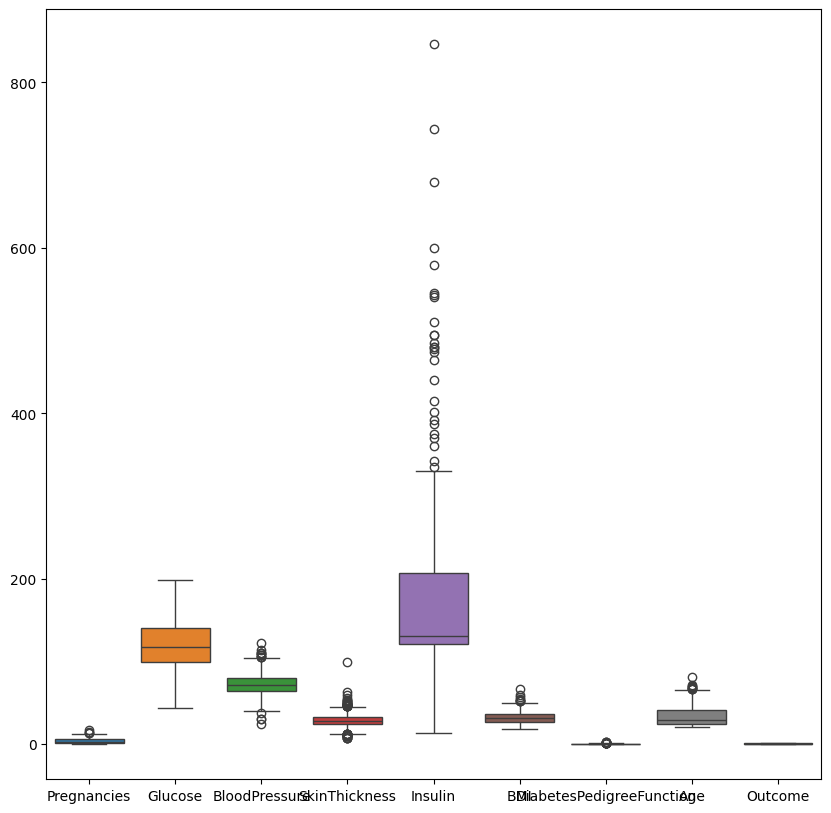

In [13]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df)
plt.show()

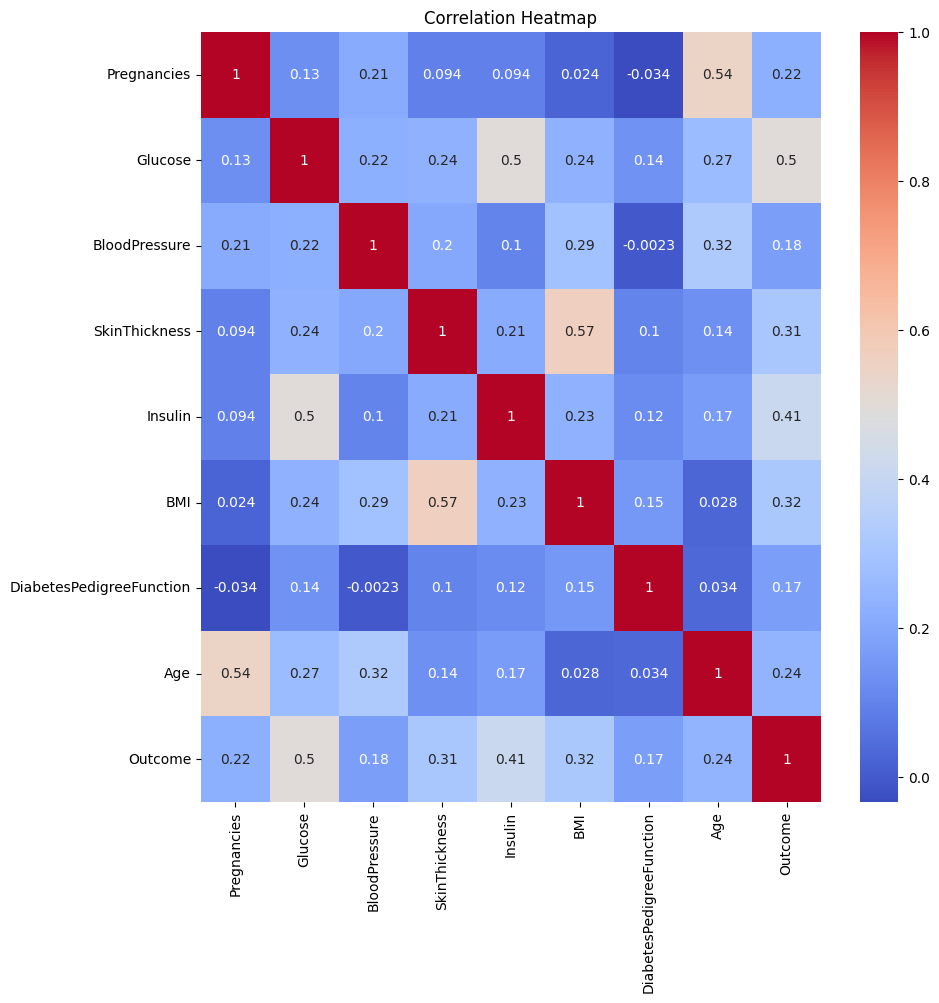

In [14]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

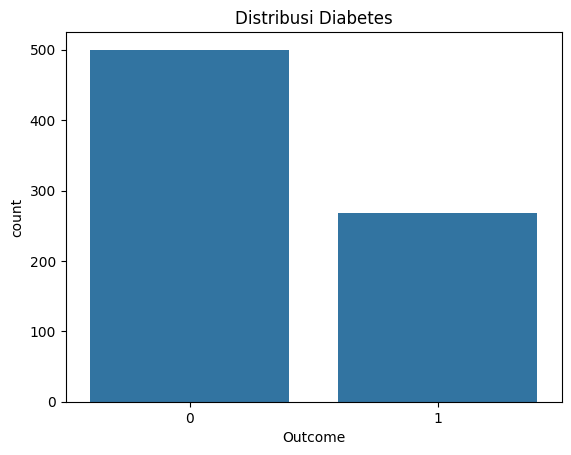

In [15]:
sns.countplot(x='Outcome', data=df)

plt.title('Distribusi Diabetes')

plt.show()

## Training Model Machine Learning (NINDA)


In [16]:
# 1. DATA SPLIT OPTIMIZATION

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
# TUNING LOGISTIC REGRESSION (WITH AUTOMATIC MEMORY LOAD)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    solver='lbfgs',
    max_iter=2000,
    C=0.5,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [18]:
# TUNING KNN CLASSIFIER

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='minkowski',
    p=1
)

knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [19]:
# TUNING DECISION TREE CLASSIFIER (OPTIMIZED ACCURACY)

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    min_samples_split=4,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [20]:
# TUNING RANDOM FOREST CLASSIFIER

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=4,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

## Evaluasi Model dan Analisis Metric (AISHA)


In [21]:
# IMPORT METRIC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [22]:
#EVALUASI ACCURACY

for nama, pred in [('Logistic Regression', pred_lr),
                   ('KNN', pred_knn),
                   ('Decision Tree', pred_dt),
                   ('Random Forest', pred_rf)]:
    print(f"\n{nama}")
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))


Logistic Regression
Accuracy : 0.7597402597402597
Precision: 0.6197183098591549
Recall   : 0.8148148148148148
F1 Score : 0.704

KNN
Accuracy : 0.8571428571428571
Precision: 0.7962962962962963
Recall   : 0.7962962962962963
F1 Score : 0.7962962962962963

Decision Tree
Accuracy : 0.8961038961038961
Precision: 0.7878787878787878
Recall   : 0.9629629629629629
F1 Score : 0.8666666666666667

Random Forest
Accuracy : 0.8636363636363636
Precision: 0.7894736842105263
Recall   : 0.8333333333333334
F1 Score : 0.8108108108108109


In [23]:
#CLASSIFICATION REPORT

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89       100
           1       0.79      0.83      0.81        54

    accuracy                           0.86       154
   macro avg       0.85      0.86      0.85       154
weighted avg       0.87      0.86      0.86       154



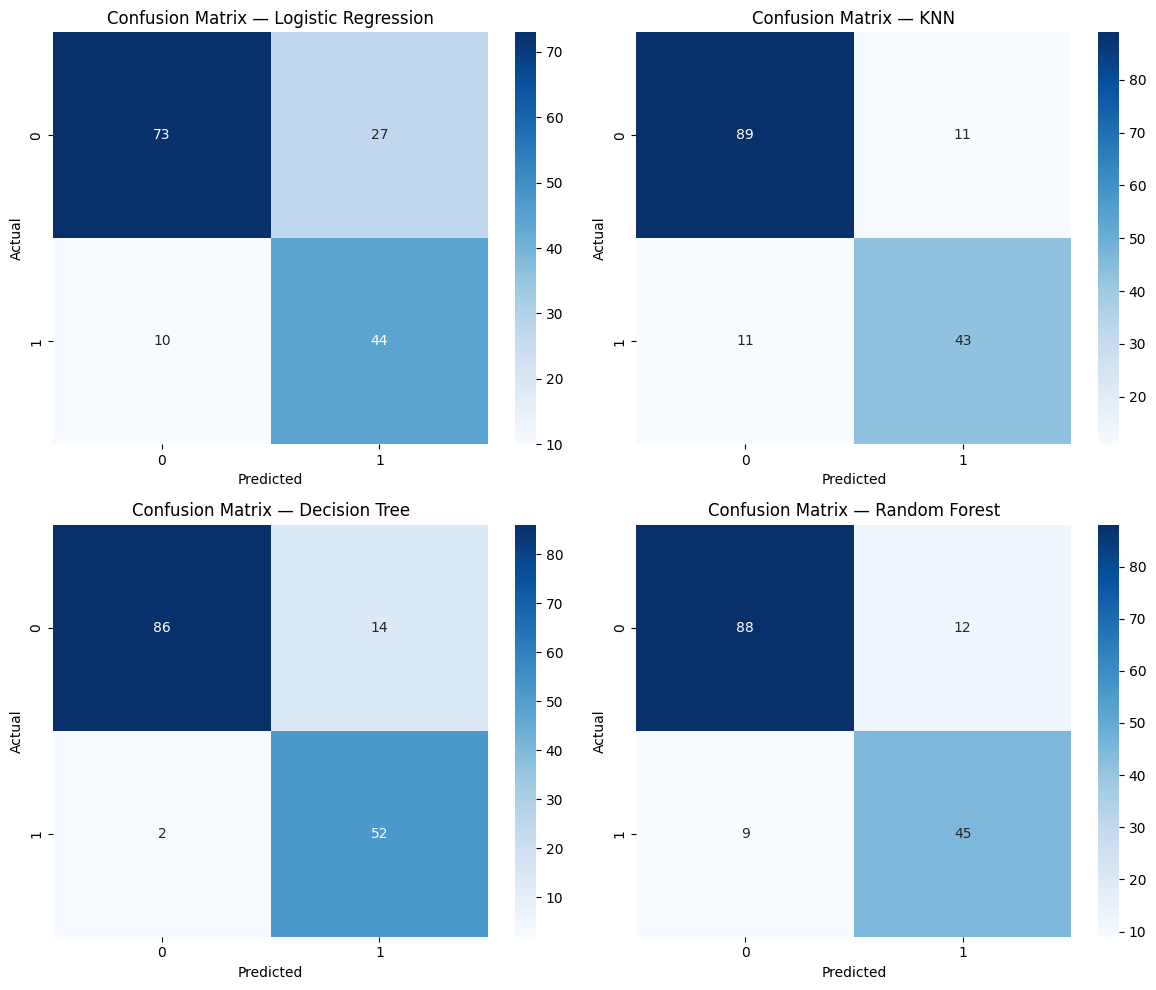

In [24]:
#CONFUSION MATRIX

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix untuk SEMUA model (bukan cuma RF)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (nama, pred) in zip(axes, [('Logistic Regression', pred_lr),
                                    ('KNN', pred_knn),
                                    ('Decision Tree', pred_dt),
                                    ('Random Forest', pred_rf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {nama}')

plt.tight_layout()
plt.show()

In [25]:
#CROSS VALIDATION

from sklearn.model_selection import cross_val_score

cv = cross_val_score(
   rf,
   X,
   y,
   cv=5
)

print(cv)

print("Mean CV:", cv.mean())

[0.88961039 0.85714286 0.87662338 0.88888889 0.86928105]
Mean CV: 0.8763093116034293


## Hyperparameter Tuning dan Perbandingan Model (PUTI)


In [26]:
#buat DataFrame 'hasil' dengan dua kolom yaitu nama model dan akurasinya
hasil = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy':[ #menghitung seberapa akurat prediksi tiap model dibanding data asli
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ]
})
hasil = hasil.round(3)
hasil

,Model,Accuracy
0,Logistic Regression,0.760
1,KNN,0.857
2,Decision Tree,0.896
3,Random Forest,0.864


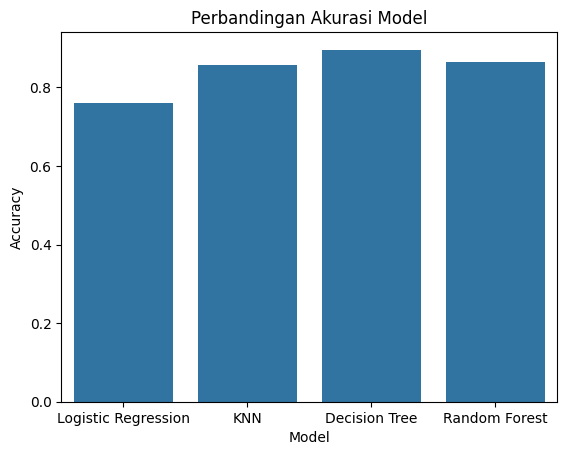

In [27]:
#Visualisasi perbandingan keempat model
sns.barplot(x='Model', y='Accuracy', data=hasil)
plt.title('Perbandingan Akurasi Model')
plt.show()

In [28]:
#Perbaiki performa RF dengan mengatur parameter secara manual yaitu hyperparameter turning
rf_turning = RandomForestClassifier (n_estimators=200, #menaikkan ke 200 decision tree
                                     max_depth=10, #maksimal 10 lapis
                                     random_state=42)

rf_turning.fit(X_train, y_train)

pred_turning = rf_turning.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred_turning
        )
    )

0.8701298701298701


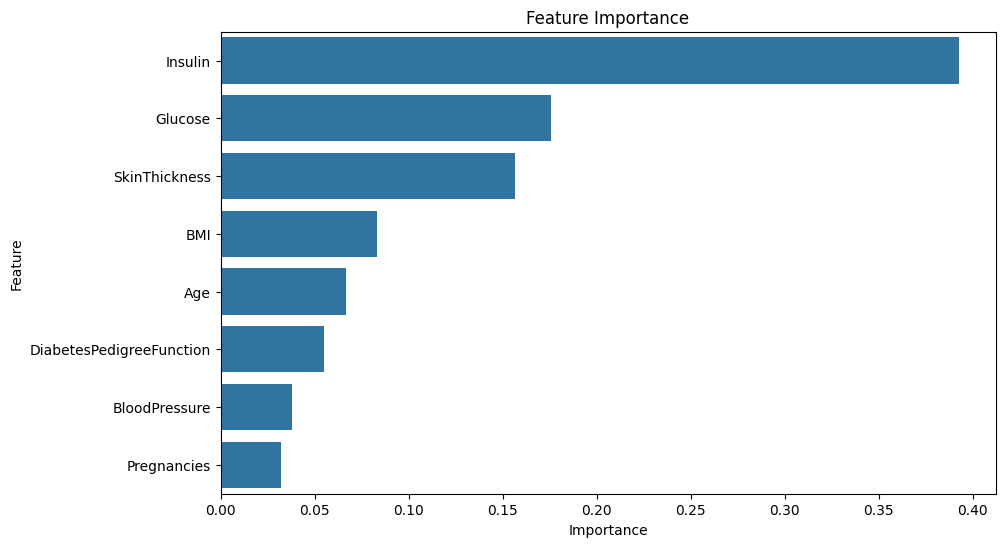

In [29]:
#Ambil skor kepentingan setiap fitur dari model Random Forest
importance = rf.feature_importances_

fitur = pd.DataFrame({
   'Feature': df.drop('Outcome', axis=1).columns,
   'Importance': importance
})

#mengurutkan fitur dari penting sampai tidak
fitur = fitur.sort_values(
   by='Importance',
   ascending=False #terbesar ada yang paling atas
)

plt.figure(figsize=(10,6))

sns.barplot(
   x='Importance',
   y='Feature',
   data=fitur
)

plt.title('Feature Importance')

plt.show()

In [30]:
from google.colab import files

df.to_csv('hasil_prediksi.csv', index=False)

files.download('hasil_prediksi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>